<a href="https://colab.research.google.com/github/kch8246/llm-korean-color-analysis/blob/main/kr_sbert_color_vocabulary_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jhgan/ko-sbert-nli
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 유사도 데이터가 'embedding_results_final.csv'로 저장되었습니다.


✅ PCA 시각화 이미지가 'color_embedding_pca.png'로 저장되었습니다.


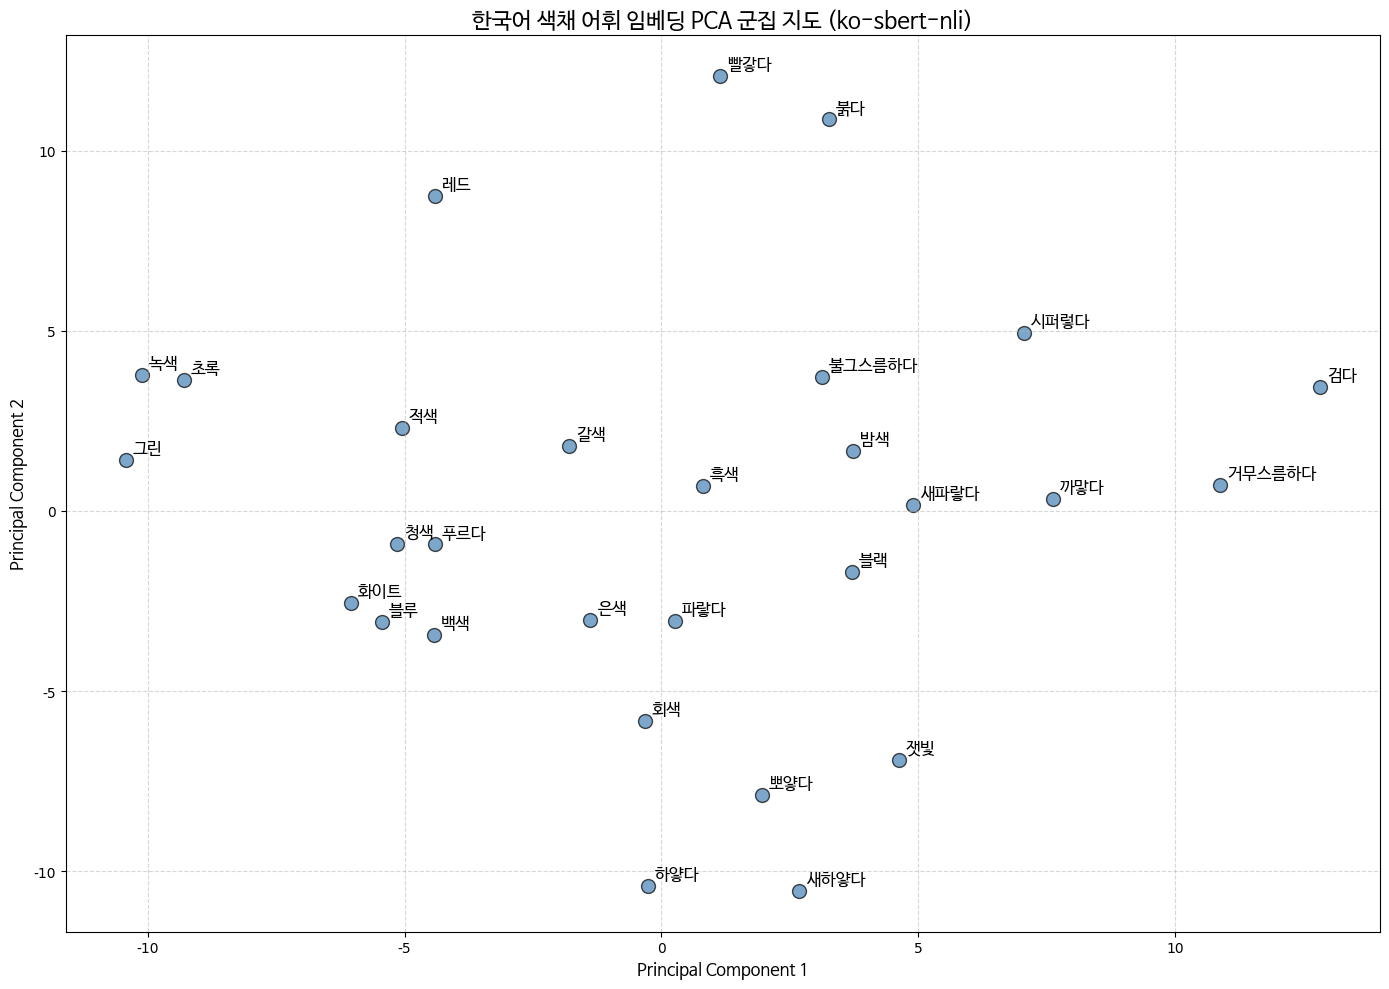

In [ ]:
!pip install -q sentence-transformers
!sudo apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 실험용 단어 리스트 (29개)
target_words = [
    # Black
    "검다", "까맣다", "거무스름하다", "흑색", "블랙",
    # Red
    "붉다", "빨갛다", "불그스름하다", "적색", "레드",
    # Blue
    "파랗다", "새파랗다", "시퍼렇다", "청색", "블루",
    # White
    "하얗다", "새하얗다", "뽀얗다", "백색", "화이트",
    # Green
    "초록", "푸르다", "녹색", "그린",
    # Neutral
    "갈색", "밤색", "잿빛", "회색", "은색"
]

# SBERT 모델 로드
print("모델을 불러오는 중입니다...")
model = SentenceTransformer('jhgan/ko-sbert-nli')

# 임베딩 벡터 추출 및 코사인 유사도 계산
embeddings = model.encode(target_words)
similarity_matrix = cosine_similarity(embeddings)

# 유사도 매트릭스를 데이터프레임으로 변환 및 CSV 저장
df_similarity = pd.DataFrame(similarity_matrix, index=target_words, columns=target_words)
df_similarity = df_similarity.round(4)
df_similarity.to_csv("embedding_results_final.csv", encoding="utf-8-sig")
print("유사도 데이터가 'embedding_results_final.csv'로 저장되었습니다.")

# PCA를 이용한 2차원 차원 축소 및 시각화
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

plt.figure(figsize=(14, 10))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='steelblue', s=100, alpha=0.7, edgecolors='k')

font_prop = fm.FontProperties(fname=font_path, size=12)
for i, word in enumerate(target_words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]),
                 xytext=(5, 5), textcoords='offset points', fontproperties=font_prop)

plt.title("한국어 색채 어휘 임베딩 PCA 군집 지도 (ko-sbert-nli)", fontproperties=fm.FontProperties(fname=font_path, size=16, weight='bold'))
plt.xlabel("Principal Component 1", fontproperties=fm.FontProperties(fname=font_path, size=12))
plt.ylabel("Principal Component 2", fontproperties=fm.FontProperties(fname=font_path, size=12))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("color_embedding_pca.png", dpi=300)
print("PCA 시각화 이미지가 'color_embedding_pca.png'로 저장되었습니다.")
plt.show()

In [ ]:
!pip install openai anthropic pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 7.7 MB/s eta 0:00:00
